In [ ]:

import torch
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import pandas as pd

import json
import sys
import os
models_path = os.path.abspath(os.path.join('models'))
sys.path.append(models_path)

from DKT.dkt_model import DKT

In [24]:

# Load the configuration file
with open('data/models/best_dkt_config.json', 'r') as f:
    config = json.load(f)

# Step 3: Instantiate the model
model = DKT(**config['models_params'])

# Step 4: Load the saved parameters
# Step 4: Load the saved parameters
model.load_state_dict(torch.load('data/models/best_dkt_model.pth', map_location=torch.device('cpu')))
model.eval()  # Set the model to evaluation mode

# Step 5: Use the model to generate embeddings
def generate_embeddings(inputs):
    with torch.no_grad():
        embedded = model.embedding(inputs[:, :, 0] * 2 - inputs[:, :, 1])
        return embedded


C:\Users\bokovacs\AppData\Local\Temp\ipykernel_4772\2612231488.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('data/models/best_dkt_mo

In [32]:
num_embeddings = int((model.embedding.num_embeddings - 1) / 2)
embedding_dim = model.embedding.embedding_dim

In [42]:

# Step 1: Create a DataFrame with `answer_id` from 1 to `num_embeddings` and `correct` set to 1
df = pd.DataFrame({
    'answer_id': range(1, num_embeddings + 1),
    'correct': 1
})

# Step 2: Calculate embeddings for each `answer_id`
# Create a tensor with the `answer_id` values, reshape to match input shape and get the embeddings
input_tensor = torch.tensor([[[i, 1] for i in range(1, num_embeddings + 1)]]).long()  # Shape: (1, num_embeddings, 2)

embeddings = generate_embeddings(input_tensor)  # Shape: (1, num_embeddings, embedding_dim)
embeddings = embeddings.squeeze(0)  # Remove the batch dimension to shape (num_embeddings, embedding_dim)

# Step 3: Add the calculated embeddings as columns to the DataFrame
# Convert embeddings to a list and add each dimension as a new column
embedding_list = embeddings.tolist()  # Shape: (num_embeddings, embedding_dim)
embedding_df = pd.DataFrame(embedding_list, columns=[f'embed_{i+1}' for i in range(embedding_dim)])

# Concatenate `df` with the embedding DataFrame
df = pd.concat([df, embedding_df], axis=1)

# Display the resulting DataFrame
print(df.head())  # Print the first few rows to check the structure


   answer_id  correct   embed_1   embed_2   embed_3   embed_4   embed_5  \
0          1        1  0.888681 -0.847292  0.213682 -2.035403  0.523639   
1          2        1 -1.134202  1.209532 -1.068941 -1.046031  0.251826   
2          3        1  0.984941  1.220255 -1.413289  1.932290  1.143891   
3          4        1  1.299874 -0.419816  0.403016 -0.235870 -0.472202   
4          5        1 -0.256645 -1.033638 -0.892583 -0.970816  0.534952   

    embed_6   embed_7   embed_8   embed_9  
0  0.101720  0.105269  0.773777 -1.094815  
1 -0.951760  1.233905  0.112118  0.792693  
2 -1.272863 -0.329960  0.675409 -1.288013  
3 -0.466357 -1.136660  0.481107 -1.238752  
4 -1.085762  1.965129  0.450252  0.393070  


C:\Users\bokovacs\AppData\Local\Temp\ipykernel_4772\2549061014.py:15: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='pca1', y='pca2', data=df, palette='viridis', alpha=0.6)


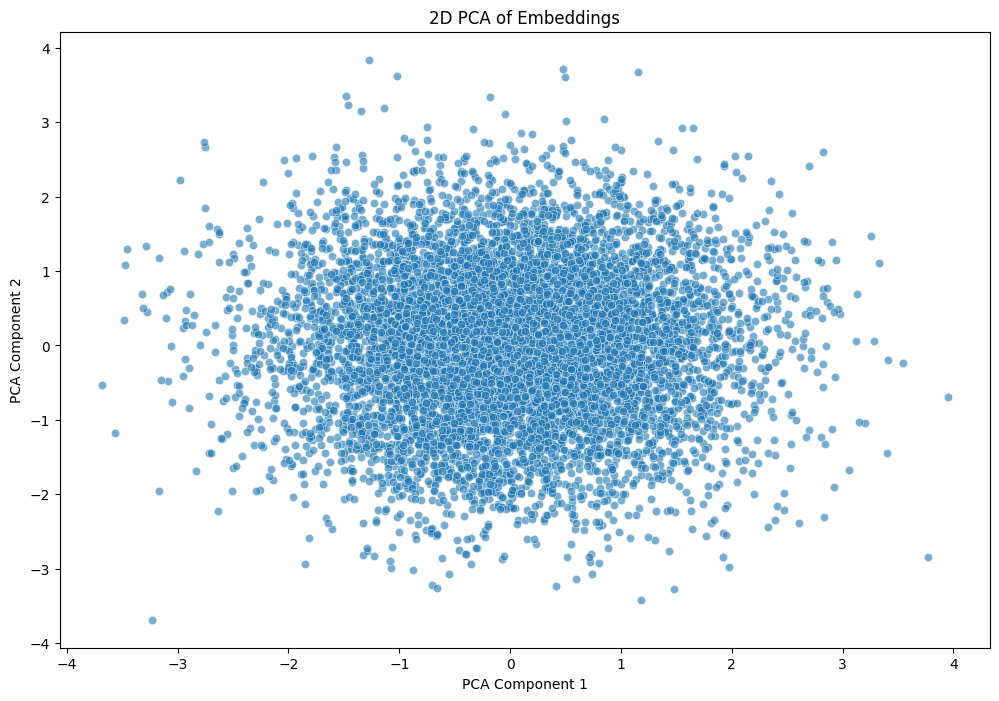

In [48]:


# Extract the embedding columns from the DataFrame
embedding_cols = [f'embed_{i}' for i in range(1, embedding_dim + 1)]  # Adjust according to the actual column names
embeddings = df[embedding_cols].values

# Apply PCA to reduce the embeddings to 2D for visualization
pca = PCA(n_components=2)
pca_result = pca.fit_transform(embeddings)

# Add PCA results to the DataFrame
df['pca1'] = pca_result[:, 0]
df['pca2'] = pca_result[:, 1]

# Plotting
plt.figure(figsize=(12, 8))
sns.scatterplot(x='pca1', y='pca2', data=df, palette='viridis', alpha=0.6)
plt.title('2D PCA of Embeddings')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()
